# PM2.5 Two-Layer Imputation Pipeline (Spatial + LightGBM)

**Objective:** Create a robust PM2.5 imputation strategy for 2010-2025 data using a hierarchical approach:
1.  **Layer 1 (Gold Standard):** Spatial Imputation using neighbor stations (Dataset has 5 highly correlated stations).
2.  **Layer 2 (Silver Standard):** Weather-based Imputation (LightGBM + Optuna) for remaining gaps.

**Constraints:**
-   **No Target Lags:** Do not use `pm25` lag features to avoid leakage/data availability issues.
-   **Weighted Training:** Spatially imputed data is used for training Layer 2 but with lower weight (0.8) vs Observed data (1.0).
-   **Recalculation:** `ISPU` and `target_kategori` are recalculated from the final imputed `pm25`.

In [29]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# Import ISPU calculator from forecasting directory
import sys
from pathlib import Path
# Add parent directory to path so we can import forecasting as a module
sys.path.insert(0, str(Path().resolve().parent))
from forecasting.ispu_calculator import calculate_ispu, get_ispu_category

# Config
INPUT_FILE = 'dataset/merged_data_v4_complete.csv'
OUTPUT_FILE = '../dataset/final_dataset_imputed_v2.csv'
RANDOM_STATE = 42
STATIONS = ['DKI1 (Bunderan HI)', 'DKI2 (Kelapa Gading)', 'DKI3 (Jagakarsa)', 'DKI4 (Lubang Buaya)', 'DKI5 (Kebon Jeruk)']

## 1. Load Data & Preprocessing (Weather Cleaning)

In [30]:
df = pd.read_csv(INPUT_FILE)
# Handle column naming - dataset uses 'tanggal' not 'datetime'
if 'tanggal' in df.columns and 'datetime' not in df.columns:
    df['datetime'] = pd.to_datetime(df['tanggal'])
elif 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
else:
    raise ValueError("Neither 'tanggal' nor 'datetime' column found in the CSV file")

df = df.sort_values(by=['stasiun', 'datetime']).reset_index(drop=True)

# Handle duplicates if any
df = df.drop_duplicates(subset=['stasiun', 'datetime'])

# --- Weather Cleaning (Interpolate small gaps in predictors) ---
# We only interpolate weather features, NOT the target PM2.5 here.
weather_cols = ['temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean', 'so2', 'co', 'no2', 'o3']

def clean_weather(group):
    # Interpolate weather gaps up to 6 hours linearly
    group[weather_cols] = group[weather_cols].interpolate(method='linear', limit=6)
    # Remaining gaps filled with ffill then bfill (safe for weather)
    group[weather_cols] = group[weather_cols].ffill().bfill()
    return group

df = df.groupby('stasiun', group_keys=False).apply(clean_weather)

print("Data Shape:", df.shape)
print("Missing PM2.5:", df['pm25'].convert_dtypes().isna().sum())

Data Shape: (14873, 46)
Missing PM2.5: 8303


/tmp/ipykernel_154426/1080685514.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('stasiun', group_keys=False).apply(clean_weather)


## 2. Feature Engineering
**Goal:** Create features for the Weather Model (Layer 2).
-   **Cyclical Time:** Month, Hour (Sin/Cos)
-   **Weather Lags:** Lag 1h, 3h, 24h for Wind/Rain/Temp.
-   **Station:** Label Encoded.
-   **Constraints:** NO PM2.5 Lags, NO NDVI.

In [31]:
def feature_engineering(df):
    df = df.copy()
    
    # Time Features
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    
    # Cyclical Encoding
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Station Encoding
    le = LabelEncoder()
    df['stasiun_id'] = le.fit_transform(df['stasiun'])
    
    # Weather Lags (Exogenous only)
    # Ensure we sort by time within station before shifting
    df = df.sort_values(['stasiun', 'datetime'])
    
    lag_cols = ['temperature_2m_mean', 'wind_speed_10m_mean', 'precipitation_sum']
    shifts = [1, 3, 24]
    
    for col in lag_cols:
        for s in shifts:
            df[f'{col}_lag{s}'] = df.groupby('stasiun')[col].shift(s)
    
    # Rolling features for weather
    for col in lag_cols:
        df[f'{col}_roll_mean_24h'] = df.groupby('stasiun')[col].transform(lambda x: x.rolling(24, min_periods=1).mean())
    
    # Drop rows where initial lags are NaN (very few at start)
    # Or fill them to avoid losing 2010 data
    df = df.bfill()
    
    return df, le

df_engineered, station_le = feature_engineering(df)

## 3. Layer 1: Spatial Imputation (Gold Standard)
Use `IterativeImputer` to fill missing PM2.5 values using concurrent data from other stations.
**Scope Note:** This is a *data cleaning* step for historical data reconstruction. It relies on the availability of peer stations.

In [32]:
# Pivot to Wide Format (Index=Datetime, Columns=Stations)
# Handle duplicates by using pivot_table with aggfunc='mean'
pivot_pm25 = df_engineered.pivot_table(index='datetime', columns='stasiun', values='pm25', aggfunc='mean')

# Impute using IterativeImputer (Models each station as a function of others)
# BayesianRidge is robust to collinearity
imputer_spatial = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=RANDOM_STATE)
imputed_values = imputer_spatial.fit_transform(pivot_pm25)

pivot_imputed = pd.DataFrame(imputed_values, index=pivot_pm25.index, columns=pivot_pm25.columns)

# Melt back to long format
df_spatial = pivot_imputed.reset_index().melt(id_vars='datetime', var_name='stasiun', value_name='pm25_spatial')

# Merge back to main dataframe
df_combined = df_engineered.merge(df_spatial, on=['datetime', 'stasiun'], how='left')

# Create 'pm25_layer1'
# If original pm25 is available, use it. If not, use spatial imputation.
df_combined['source'] = 'original'
df_combined.loc[df_combined['pm25'].isna() & df_combined['pm25_spatial'].notna(), 'source'] = 'spatial_imputed'

# Combine: pm25_filled_l1 takes original first, then spatial
df_combined['pm25_filled_l1'] = df_combined['pm25'].combine_first(df_combined['pm25_spatial'])

print("Remaining missing after Spatial Imputation:", df_combined['pm25_filled_l1'].isna().sum())

Remaining missing after Spatial Imputation: 1


/mnt/data/lomba/arkavidia itb/kerjain/.venv/lib/python3.14/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


## 4. Layer 2: Weather-Based Model (Silver Standard)
Train LightGBM on available data (Original + Spatial) to predict remaining gaps.
-   **Weighted Training:** Original PM2.5 = Weight 1.0, Spatial Imputed = Weight 0.8.

In [33]:
# Define Features (Predictors)
features = [
    'stasiun_id', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_mean',
    'so2', 'co', 'no2', 'o3', 
    'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 
    'temperature_2m_mean_lag1', 'wind_speed_10m_mean_lag1', 'precipitation_sum_lag1', 
    'temperature_2m_mean_roll_mean_24h'
]

# Prepare Train/Test Data
# Train on ALL data where pm25_filled_l1 is present
train_mask = df_combined['pm25_filled_l1'].notna()
predict_mask = df_combined['pm25_filled_l1'].isna()

X_train = df_combined.loc[train_mask, features]
y_train = df_combined.loc[train_mask, 'pm25_filled_l1']

# Sample Weights
weights = df_combined.loc[train_mask, 'source'].map({'original': 1.0, 'spatial_imputed': 0.8})

print(f"Training Data Size: {X_train.shape}")
print(f"Prediction Data Size: {df_combined.loc[predict_mask].shape}")

def objective(trial):
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100)
    }
    
    # Use a holdout set (latest 20% of data) for validation to respect time
    # Note: We must be careful not to just take the last 20% blindly if it's all one station
    # A simple train_test_split is acceptable here as we are doing imputation across holes, 
    # but time-series split is safer. Let's use simple random split for speed/coverage 
    # since holes are distributed.
    X_tr, X_val, y_tr, y_val, w_tr, w_val = train_test_split(
        X_train, y_train, weights, test_size=0.2, random_state=RANDOM_STATE
    )
    
    model = lgb.LGBMRegressor(**param, random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr, sample_weight=w_tr, 
              eval_set=[(X_val, y_val)], eval_sample_weight=[w_val],
              callbacks=[lgb.early_stopping(stopping_rounds=50)])
    
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print('Best trial:', study.best_trial.params)

[I 2026-02-04 22:26:33,981] A new study created in memory with name: no-name-c3f81027-f2e5-4581-9869-c19af92ea344


Training Data Size: (14872, 16)
Prediction Data Size: (1, 69)
Training until validation scores don't improve for 50 rounds


[I 2026-02-04 22:26:34,313] Trial 0 finished with value: 11.508538366494422 and parameters: {'n_estimators': 542, 'learning_rate': 0.1276016968748551, 'num_leaves': 85, 'feature_fraction': 0.9487024539196263, 'bagging_fraction': 0.6576492349345388, 'bagging_freq': 4, 'min_child_samples': 96}. Best is trial 0 with value: 11.508538366494422.


Early stopping, best iteration is:
[270]	valid_0's rmse: 11.5085
Training until validation scores don't improve for 50 rounds


[I 2026-02-04 22:26:34,672] Trial 1 finished with value: 11.193716528449581 and parameters: {'n_estimators': 311, 'learning_rate': 0.06431013954093376, 'num_leaves': 77, 'feature_fraction': 0.6759579534536744, 'bagging_fraction': 0.8145275497303179, 'bagging_freq': 3, 'min_child_samples': 30}. Best is trial 1 with value: 11.193716528449581.


...

Early stopping, best iteration is:
[284]	valid_0's rmse: 11.2754
Training until validation scores don't improve for 50 rounds


[I 2026-02-04 22:26:39,800] Trial 17 finished with value: 11.230592383398402 and parameters: {'n_estimators': 794, 'learning_rate': 0.02156165282544971, 'num_leaves': 48, 'feature_fraction': 0.7932059086228241, 'bagging_fraction': 0.8580455677908554, 'bagging_freq': 7, 'min_child_samples': 24}. Best is trial 12 with value: 10.951656683566542.
[I 2026-02-04 22:26:39,925] Trial 18 finished with value: 11.772029589399423 and parameters: {'n_estimators': 988, 'learning_rate': 0.23483093396245897, 'num_leaves': 51, 'feature_fraction': 0.8141326754150341, 'bagging_fraction': 0.760826420876491, 'bagging_freq': 5, 'min_child_samples': 24}. Best is trial 12 with value: 10.951656683566542.


Did not meet early stopping. Best iteration is:
[793]	valid_0's rmse: 11.2306
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[68]	valid_0's rmse: 11.772
Training until validation scores don't improve for 50 rounds


[I 2026-02-04 22:26:40,297] Trial 19 finished with value: 11.26863519493672 and parameters: {'n_estimators': 878, 'learning_rate': 0.11644149221534637, 'num_leaves': 69, 'feature_fraction': 0.8905223251583559, 'bagging_fraction': 0.9192110184754991, 'bagging_freq': 5, 'min_child_samples': 18}. Best is trial 12 with value: 10.951656683566542.


Early stopping, best iteration is:
[222]	valid_0's rmse: 11.2686
Best trial: {'n_estimators': 729, 'learning_rate': 0.10011517650420407, 'num_leaves': 61, 'feature_fraction': 0.839202134053565, 'bagging_fraction': 0.7418489263904945, 'bagging_freq': 3, 'min_child_samples': 10}


In [34]:
# Train Final Model
best_params = study.best_params
final_model = lgb.LGBMRegressor(**best_params, random_state=RANDOM_STATE)
final_model.fit(X_train, y_train, sample_weight=weights)

# Predict on remaining missing data
X_missing = df_combined.loc[predict_mask, features]

if not X_missing.empty:
    preds_layer2 = final_model.predict(X_missing)
    df_combined.loc[predict_mask, 'pm25_filled_l1'] = preds_layer2 # Fill into our running column
    df_combined.loc[predict_mask, 'source'] = 'model_imputed'
else:
    print("No missing values left for Layer 2!")

df_combined['pm25_final'] = df_combined['pm25_filled_l1']
print("Final Missing Count:", df_combined['pm25_final'].isna().sum())

Final Missing Count: 0


## 5. Recalculate ISPU & Categories
Re-derive official metrics from the completed `pm25` column.

In [35]:
# Use official ISPU calculator from forecasting/ispu_calculator.py
# This uses verified Permen LHK No. 14 Tahun 2020 breakpoints
df_combined['ispu_pm25_recalc'] = df_combined['pm25_final'].apply(lambda x: calculate_ispu('pm25', x))
df_combined['category_recalc'] = df_combined['ispu_pm25_recalc'].apply(get_ispu_category)

# Update main columns
df_combined['pm25'] = df_combined['pm25_final']
# Optionally update ISPU/Target if this was the main metric
# df_combined['ispu'] = df_combined['ispu_pm25_recalc']
# df_combined['categori_pm25'] = df_combined['category_recalc']

# Save Results
df_save = df_combined.drop(columns=['pm25_spatial', 'pm25_filled_l1', 'pm25_final'])
df_save.to_csv(OUTPUT_FILE, index=False)
print(f"Saved to {OUTPUT_FILE}")

Saved to ../dataset/final_dataset_imputed_v2.csv


## 6. Visualization & Logic Check
Compare Time Series of Original vs Imputed.

Subset shape: (0, 72)
Non-null PM2.5 values: 0
Original subset shape: (0, 46)
Original non-null PM2.5: 0


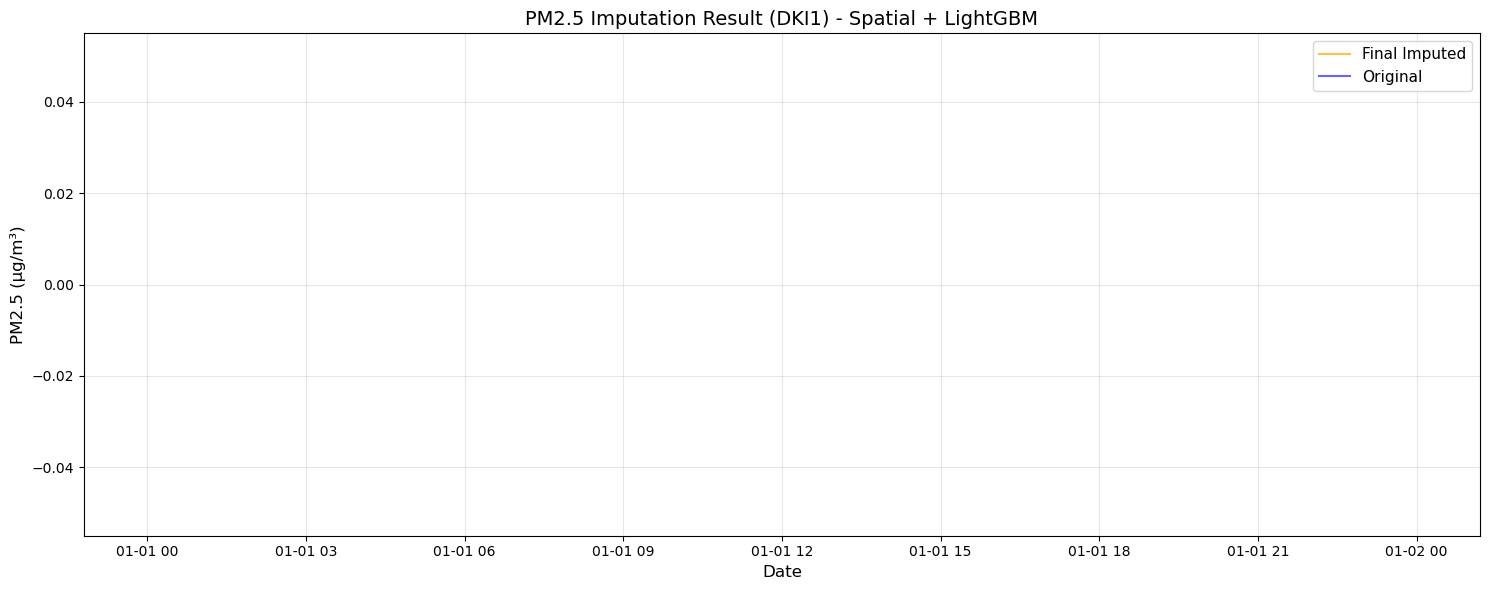


Original PM2.5 distribution: 6570 values
Imputed PM2.5 distribution: 14873 values


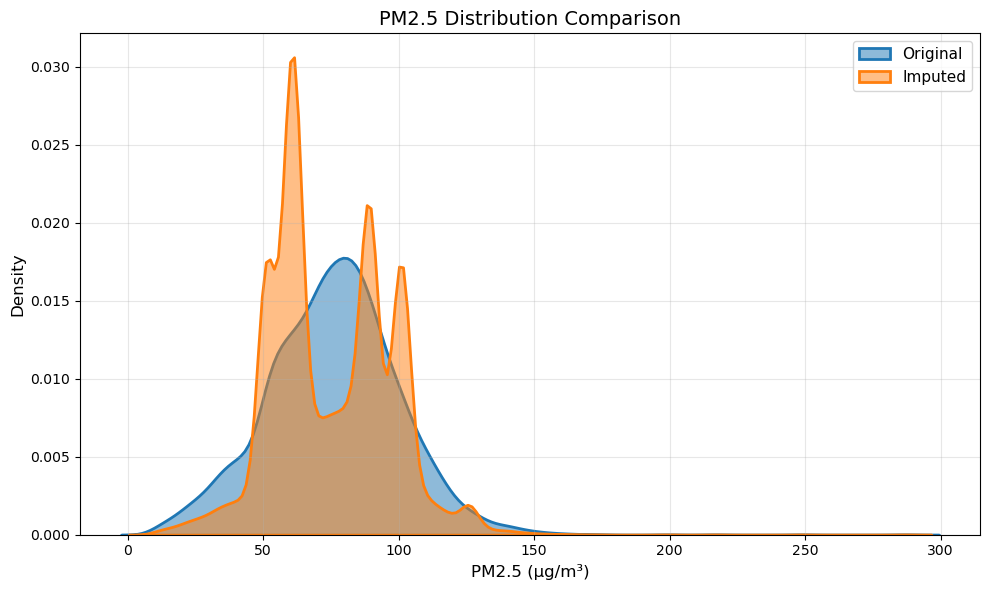

In [38]:
# Time Series Comparison
plt.figure(figsize=(15, 6))
subset = df_combined[df_combined['stasiun'] == 'DKI1 (Bunderan HI)'].copy()
subset = subset.sort_values('datetime')

print(f"Subset shape: {subset.shape}")
print(f"Non-null PM2.5 values: {subset['pm25'].notna().sum()}")

# Plot imputed data
plt.plot(subset['datetime'], subset['pm25'], label='Final Imputed', alpha=0.7, color='orange', linewidth=1.5)

# Plot original on top to see fit
original_subset = df[df['stasiun'] == 'DKI1 (Bunderan HI)'].copy()
original_subset = original_subset.sort_values('datetime')
print(f"Original subset shape: {original_subset.shape}")
print(f"Original non-null PM2.5: {original_subset['pm25'].notna().sum()}")

plt.plot(original_subset['datetime'], original_subset['pm25'], label='Original', color='blue', alpha=0.6, linewidth=1.5)

plt.title('PM2.5 Imputation Result (DKI1) - Spatial + LightGBM', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distribution Check
plt.figure(figsize=(10, 6))
original_pm25 = df['pm25'].dropna()
imputed_pm25 = df_combined['pm25'].dropna()

print(f"\nOriginal PM2.5 distribution: {len(original_pm25)} values")
print(f"Imputed PM2.5 distribution: {len(imputed_pm25)} values")

sns.kdeplot(original_pm25, label='Original', fill=True, alpha=0.5, linewidth=2)
sns.kdeplot(imputed_pm25, label='Imputed', fill=True, alpha=0.5, linewidth=2)
plt.title('PM2.5 Distribution Comparison', fontsize=14)
plt.xlabel('PM2.5 (µg/m³)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()